# Wildfires in the US
## An Application of Geopandas, Rasterio, and Zonalstats

In [1]:
import numpy
import matplotlib.pyplot as plt
import geopandas
import pyproj
import rasterio
import rasterstats

In [2]:
data_dir = "C:/Users/jhtchns2/Box/ACE_592_SAE/Class_Examples/2_Images/"

The objective of this lecture is to demonstrate how to:
1. Read shape files.
2. Read and edit rasters.
3. Calculate zonal stats from:
    - A raster and a shape file
    - A shape file and a shape file


## Step 1: Reading shape files

### US States
Below is a geojson file of US states which is read into the dataframe as a geopandas dataframe

In [3]:
# Create file directory to read from
state_file = data_dir + "us_states.json"
# Read that json file
country = geopandas.read_file(state_file)

What is a geopandas dataframe?

Essentially, it is the same as a pandas dataframe but with geographic methods. For example:
- It has a column called "geometry" which stores a `shapely` polygon or multi-polygon object.
- Has geographic information embedded (like the CRS).
- Default plot method makes a spatial plot.

In [4]:
# Show you the first 5 rows
country.head()

,GEO_ID,STATE,NAME,LSAD,CENSUSAREA,geometry
0,0400000US01,01,Alabama,,50645.326,"MULTIPOLYGON (((-88.12466 30.28364, -88.08681 ..."
1,0400000US02,02,Alaska,,570640.950,"MULTIPOLYGON (((-166.10574 53.98861, -166.0752..."
2,0400000US04,04,Arizona,,113594.084,"POLYGON ((-112.53859 37.00067, -112.53454 37.0..."
3,0400000US05,05,Arkansas,,52035.477,"POLYGON ((-94.04296 33.01922, -94.04304 33.079..."
4,0400000US06,06,California,,155779.220,"MULTIPOLYGON (((-122.42144 37.86997, -122.4213..."


<class 'shapely.geometry.multipolygon.MultiPolygon'>


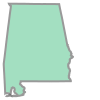

In [5]:
# What type of object is this?
print(type(country['geometry'][0]))
# What does it look like?
country['geometry'][0]

In [6]:
# What is the CRS?
country.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

<Axes: >

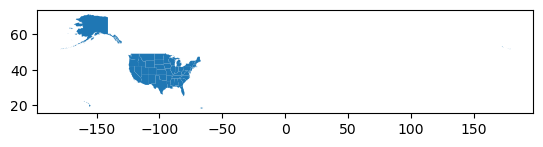

In [8]:
# Plot all of the geometry
country.plot()

The frame is a bit big. What if we just wanted to look at the continental US?

Do what you would do usually with a Pandas dataframe!

<Axes: >

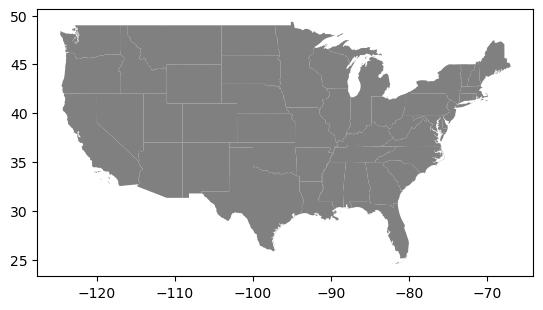

In [9]:
# Give me state names NOT in that list
country = country[~country['NAME'].isin(["Alaska","Hawaii","Puerto Rico"])]
# Plot it, but grey
country.plot(color="Grey")

These dataframes have very useful methods and attributes:
- `centroid`, which can extract the centroid from the shape.
- `to_crs()`, which can change the projection.
- `distance()`, which can tell you the distance between each row and a specific geometry.

Let's use these methods to find the distance between the Alabama centroid and every other state centroid.

C:\Users\jhtchns2\AppData\Local\Temp\ipykernel_28896\2476596349.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  country.centroid.plot(ax=a,color="white")


<Axes: >

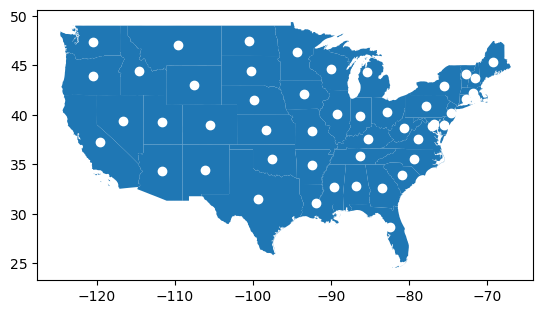

In [10]:
f,a = plt.subplots()
# Plot all the states
country.plot(ax=a)
# Plot all the centroids
country.centroid.plot(ax=a,color="white")

User warning! What did we do wrong?

<Axes: >

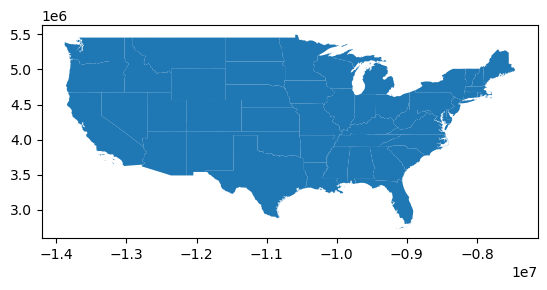

In [11]:
# Reproject into a projected CRS 
country_proj = country.to_crs(epsg=4087) # WGS 84 Equidistant Cylndrical
# Plot the projected one
country_proj.plot()

In [12]:
# Now look at the centroids 
country_proj.centroid.head()

0     POINT (-9665692.036 3650141.472)
2    POINT (-12430444.498 3817508.335)
3    POINT (-10290293.085 3885021.352)
4    POINT (-13314999.483 4146226.165)
5     POINT (-11749529.566 4341298.65)
dtype: geometry

<Axes: >

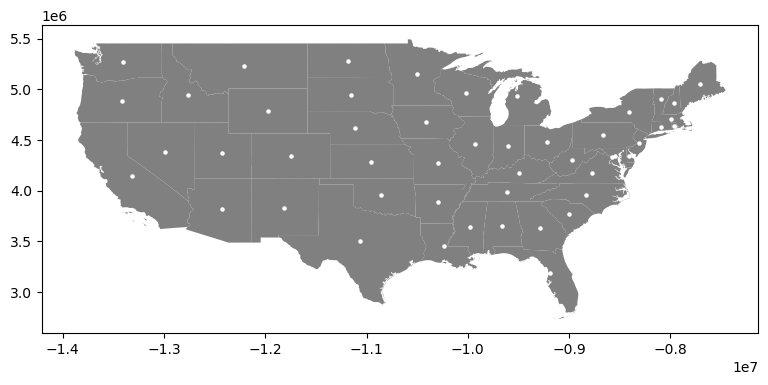

In [13]:
f,a = plt.subplots(figsize=(10,4))
# PLot the country
country_proj.plot(ax=a,zorder=1,color='gray')
# plot the centroids
country_proj.centroid.plot(ax=a,color="white",markersize=5)

The `distance` function works on a series, but requires a geometry object to be passed right to the function.

In [14]:
# Find the "Bama" centroid
bama_cent = country_proj.centroid[0]
# Distance btwn Bama and every other centroid
country_proj['bama_dist'] = country_proj.centroid.distance(bama_cent)/1000 # res is in meters, so converting to km
# Sort by distance, show closest 5
country_proj.sort_values("bama_dist").head()

,GEO_ID,STATE,NAME,LSAD,CENSUSAREA,geometry,bama_dist
0,0400000US01,01,Alabama,,50645.326,"MULTIPOLYGON (((-9809992.055 3371159.384, -980...",0.000000
24,0400000US28,28,Mississippi,,46923.274,"MULTIPOLYGON (((-9918079.384 3365384.908, -991...",315.813389
42,0400000US47,47,Tennessee,,41234.896,"POLYGON ((-9292072.558 4073991.019, -9281251.8...",344.144784
10,0400000US13,13,Georgia,,57513.485,"POLYGON ((-9441059.114 3894802.595, -9440915.1...",376.844636
17,0400000US21,21,Kentucky,,39486.338,"MULTIPOLYGON (((-9961436.434 4062904.489, -996...",554.402258


Text(0.5, 1.0, 'State Centroid Distance from Alabama')

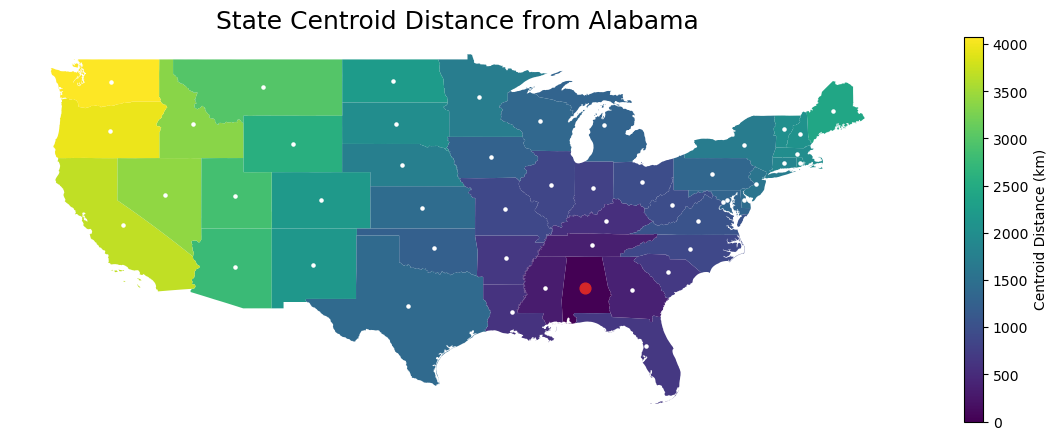

In [15]:
f,a = plt.subplots(figsize=(15,5))
# Plot the dataframe
country_proj.plot(column="bama_dist", # This is what I color the states with
                  ax=a, # Axis
                  legend=True, # This makes a colorbar 
                  legend_kwds={'label': "Centroid Distance (km)"}); # This labels the colorbar
# Plot the first centroid in red (C3)
country_proj.centroid[:1].plot(color="C3",ax=a,markersize=60);
# Plot the other centroids in white (w)
country_proj.centroid[1:].plot(color="w",ax=a,markersize=5);
# Turn the axis off
plt.axis("off");
# Title the plot
plt.title("State Centroid Distance from Alabama",fontsize=18)


### Notice:
Some cool functionality of the plotting function is that it has built in ability to do chloropleth maps very easily!

Going back to the code that I just wrote:

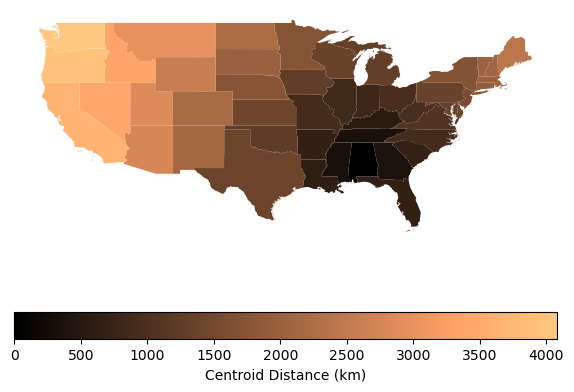

In [16]:
f,a = plt.subplots(figsize=(7,6))
country_proj.plot(column="bama_dist", # Same column as before
                  ax=a,
                  cmap="copper", # Different colormap
                  legend=True, # Colorbar
                  legend_kwds={'label': "Centroid Distance (km)", # This time,
                               'orientation': "horizontal"}); # Make it on the bottom!
plt.axis("off");
plt.savefig("war_eagle_roll_tide.png",dpi=300)

## Wildfires
To demonstrate spatial joins, let's say we want to look at wildfires. NASA keeps a very [nice database on active fires](https://firms.modaps.eosdis.nasa.gov/active_fire/#firms-shapefile).

This one is a shapefile from NASA which was collected using their MODIS instrument. These are all the fires from October 20th 2020 until October 27th 2020.

In [17]:
# Read in as a geodataframe
fires = geopandas.read_file(data_dir+"MODIS_C6_USA_contiguous_and_Hawaii_7d.shp")

Before we go plotting them together, let's do a projection check.

#### Projection check

In [18]:
# Are these the same CRS?
country.crs == fires.crs

True

We're good to go!

Notice that instead of "polygons," we have "point" objects.

If we plot them on top of each other we get this:

<Axes: >

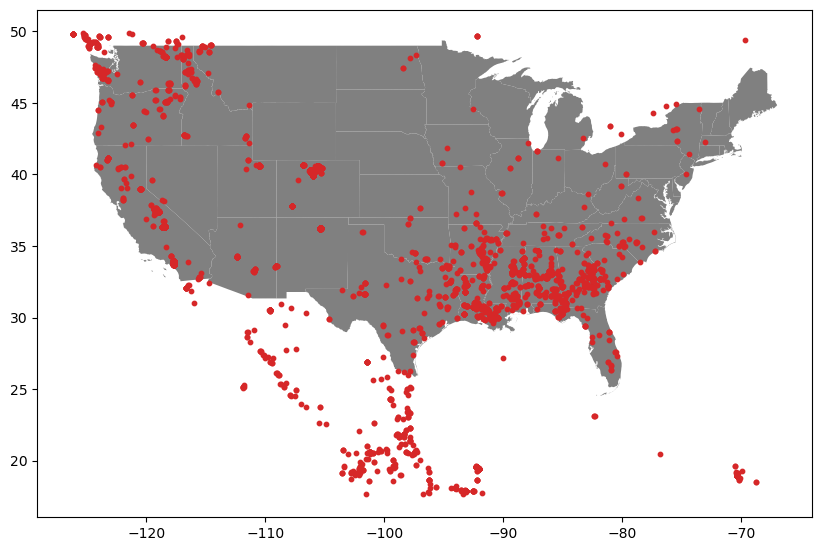

In [19]:
f,a = plt.subplots(figsize=(10,10))
# Plot the country
country.plot(ax=a,color="grey")
# Plot the fires
fires.plot(color="C3",markersize=10,ax=a)

So notice that our fire data is in Mexico as well as Canada. How do we only look at fires in the US?

Intuitively, we look for the overlap. Restricting a shape file based on another shapefile is called __clipping__.

Geopandas has a great clipping function: 

In [20]:
print(fires.shape)

print(geopandas.clip(fires,country).shape)

(3872, 14)
(3310, 14)


The first argument is the thing you want clipped, the second argument is the mask used to clip it.

So it looks like clipping got rid of about 500 fires.

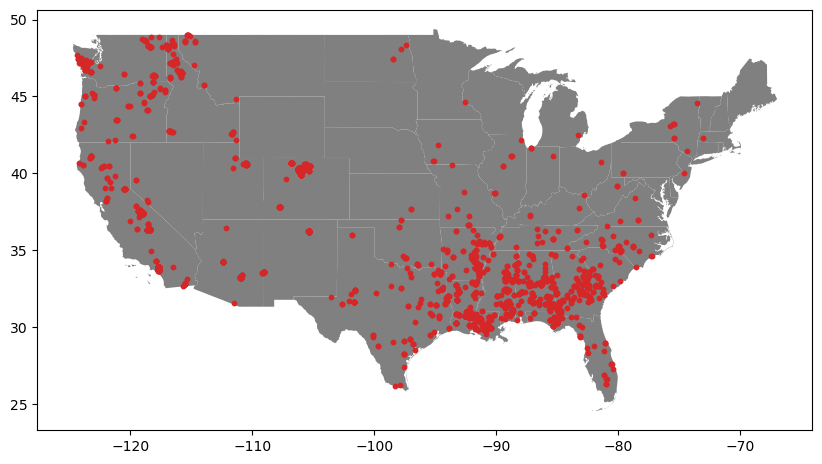

In [21]:
# The clip function's two arguments are
# 1. The thing you want clipped (bigger)
# 2. The thing you want to clip it to (smaller)
fires = geopandas.clip(fires,country)

f,a = plt.subplots(figsize=(10,10))
country.plot(ax=a,color="grey")
fires.plot(color="C3",markersize=10,ax=a);

Using the geopandas plotting function, we can actually color the dots according to one of the variables.

We will do it here according to the column "brightness."

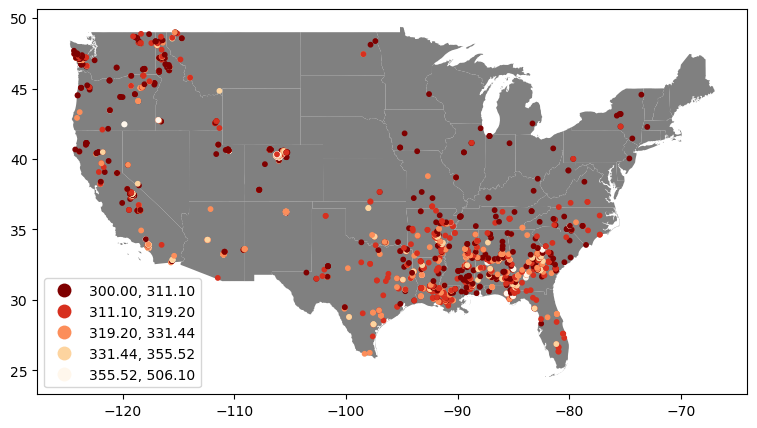

In [22]:
f,a = plt.subplots(figsize=(10,5))
# Plot the country
country.plot(ax=a,color="grey")
# Clipped fires
clipped = geopandas.clip(fires,country)
# Plot the fires
clipped.plot(markersize=10, # Marker size
             ax=a, # Axis
             column='BRIGHTNESS', # Color by brightness
             cmap="OrRd_r", # Use Orange-Red colormap, but reversed
             scheme='quantiles', # Look at quantiles
             legend=True); # Legend

### What is a spatial join?
Spatial joining is essentially executing a merge between two shapefiles. Instead of using indexes it uses their spatial positions.

For example, what if we wanted to count the number of fires in a given state?

In [23]:
# The sjoin arguments are:
# Left shapefile
# Right shapefile
fires_w_state = geopandas.sjoin(fires,\
                                country,\
                                how='left')

state_w_fires = geopandas.sjoin(fires,\
                                country,\
                                how='right')

fires_w_state.shape, state_w_fires.shape


((3310, 20), (3322, 20))

They look about the same size, what was the difference between the left and right merge?

In [24]:
fires_w_state.head().geometry, \
state_w_fires.head().geometry

(3226    POINT (-90.832 29.588)
 3227    POINT (-90.886 29.802)
 3228    POINT (-90.968 29.809)
 3358    POINT (-90.956 29.816)
 1025    POINT (-90.791 29.817)
 Name: geometry, dtype: geometry,
 0    MULTIPOLYGON (((-88.12466 30.28364, -88.08681 ...
 0    MULTIPOLYGON (((-88.12466 30.28364, -88.08681 ...
 0    MULTIPOLYGON (((-88.12466 30.28364, -88.08681 ...
 0    MULTIPOLYGON (((-88.12466 30.28364, -88.08681 ...
 0    MULTIPOLYGON (((-88.12466 30.28364, -88.08681 ...
 Name: geometry, dtype: geometry)

With spatial joins in geopandas dataframes, only one set of geometry will be retained. So make sure you understand how you are merging things!

Both of these dataframes could be useful in different ways.

Text(0.5, 1.0, 'Fires Colored by Census Area')

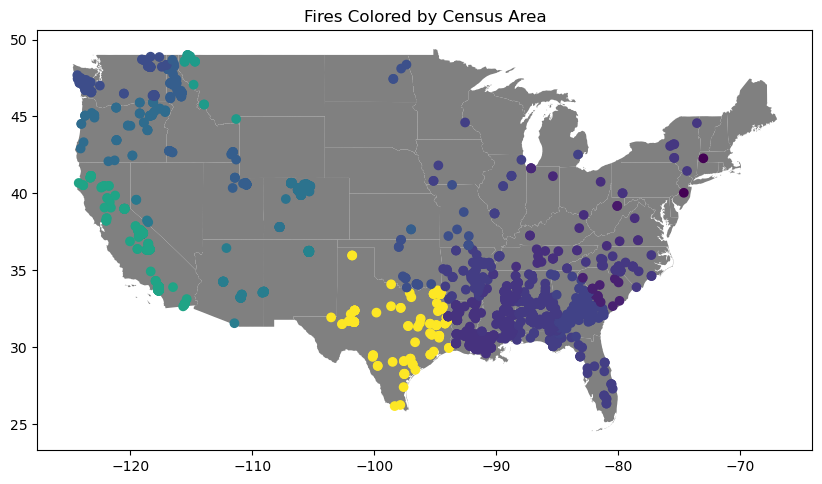

In [25]:
f,a = plt.subplots(figsize=(10,10))
# Plot the country
country.plot(color='gray',ax=a)
# Plot the fires by census area (an attribute of the states)
fires_w_state.plot(column="CENSUSAREA",ax=a)
# 
plt.title("Fires Colored by Census Area")

Let's get a count of fires per state.

In [26]:
# Count the number of times each state name occurs
state_w_fires.value_counts("NAME").head()

NAME
Colorado      1221
California     722
Louisiana      200
Alabama        155
Georgia        142
Name: count, dtype: int64

In [27]:
# Group by state name, count the number of indices ("index_left"), reset_index
state_fire_counts = state_w_fires.groupby("NAME")['index_left'].count().reset_index()
# Rename the "index_left" to "fire_number"
state_fire_counts.columns = ["NAME","fire_number"]
# Look at first 5 rows
state_fire_counts.head()

,NAME,fire_number
0,Alabama,155
1,Arizona,65
2,Arkansas,88
3,California,722
4,Colorado,1221


In [28]:
# Merge in the state-level fire counts (merge on "NAME")
country = country.merge(state_fire_counts,how='left',on="NAME")

<Axes: >

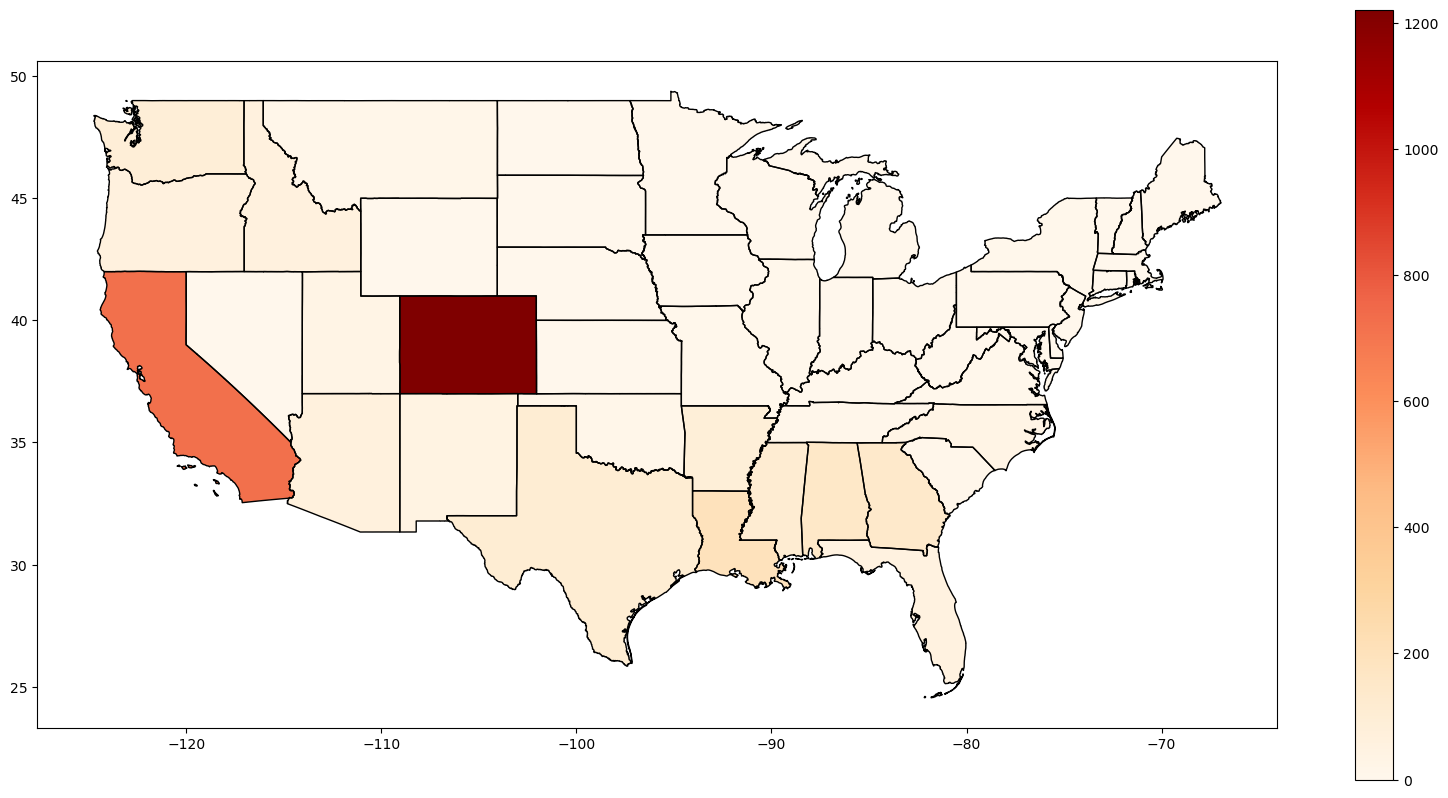

In [29]:
f,a = plt.subplots(figsize=(20,10))

country.plot(column="fire_number", # Plot the number of fires
             ax=a, # On this axis
             cmap="OrRd", # Using Orange-Red colormap
            legend=True) # Colorbar
# 
country.plot(ax=a,facecolor='none', edgecolor='black')

California and Colorado are clear outliers, could use the quantile method instead.

<Axes: >

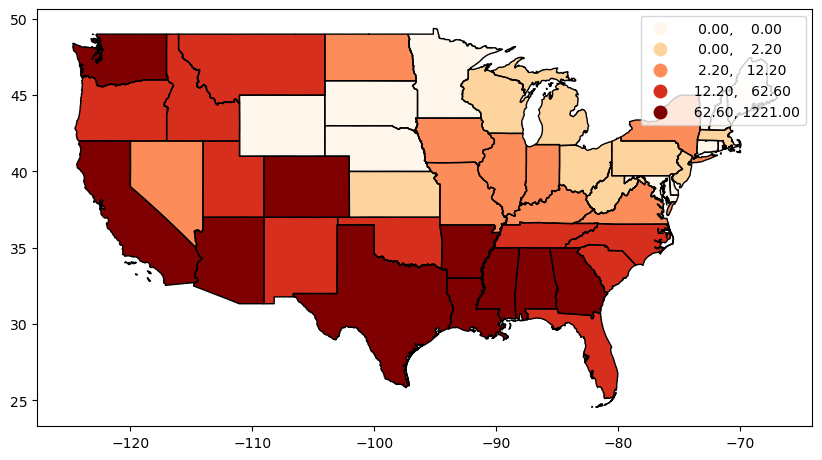

In [30]:
f,a = plt.subplots(figsize=(10,10))

country.plot(column="fire_number", # Plot fires
             ax=a, # Axis
             cmap="OrRd", # Colormap
             scheme="quantiles", # Use quantiles
             legend=True) # PRoduce legend of quantiles

# Plot empty states (with no color)
country.plot(ax=a,facecolor='none', edgecolor='black')

Another way to deal with extremes is to set `vmax` and `vmin`, the max and min values of the colormap

<Axes: >

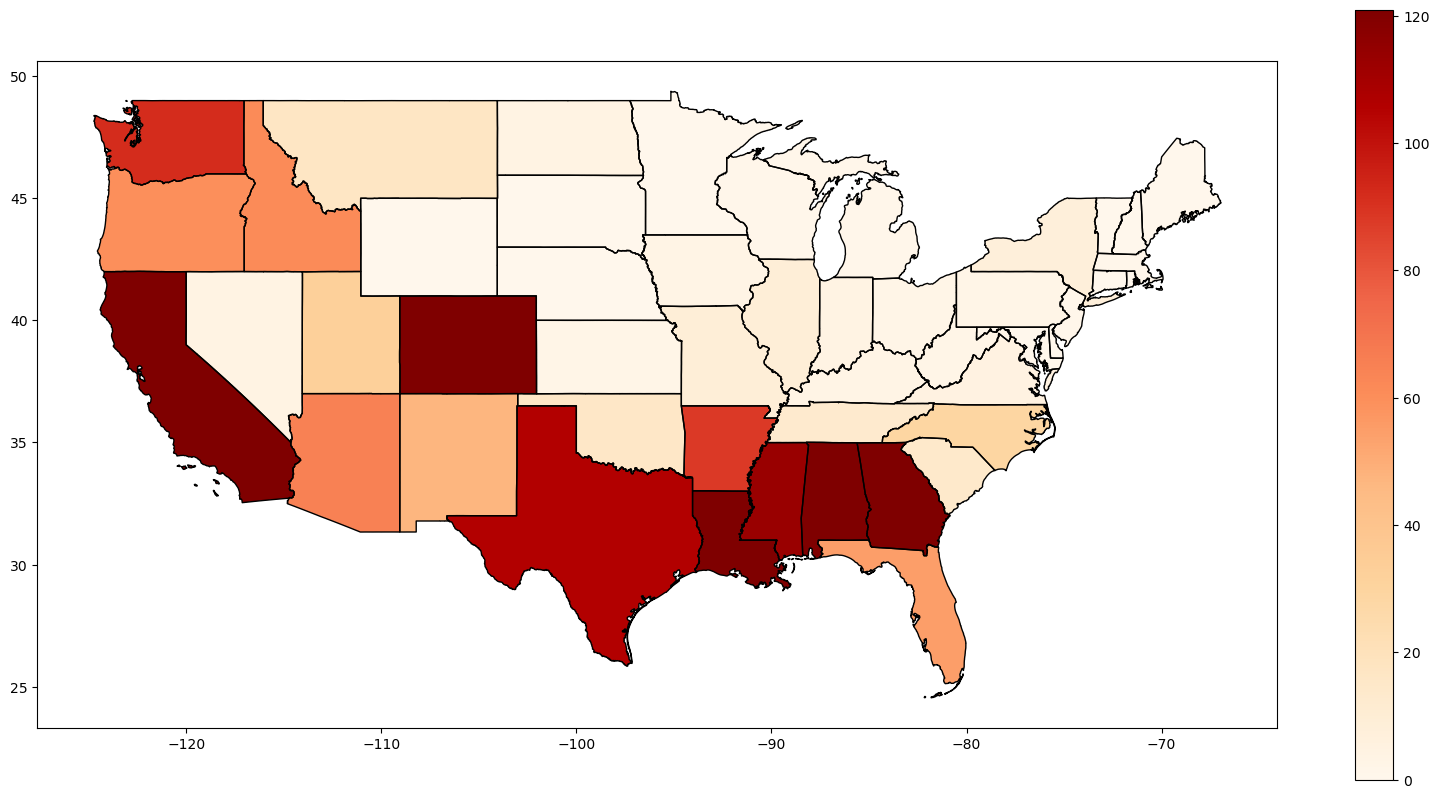

In [31]:
f,a = plt.subplots(figsize=(20,10))

country.plot(column="fire_number", # Plot the number of fires
             ax=a, # On this axis
             cmap="OrRd", # Using Orange-Red colormap
             vmax=121,
             vmin=0,
            legend=True) # Colorbar
# 
country.plot(ax=a,facecolor='none', edgecolor='black')

### Dissolves

What if we wanted to merge polygons into one polygons? This is called a __dissolve__.

Geopandas make this very easy.

<Axes: >

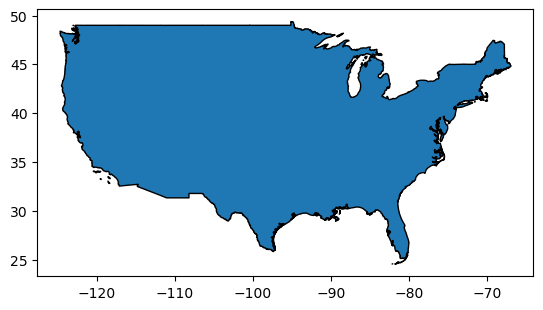

In [32]:
# A column with one value, "USA"
country['country'] = "USA"
# The arguments of dissolve are:
# by: The key you are dissolving on
# aggfunc: How you aggregate the information in each geometry
dissolved = country.dissolve(by="country",aggfunc="sum")
# Plot the dissolved polygon
dissolved.plot(edgecolor="black")

Or do it based on something arbitrary:

<Axes: >

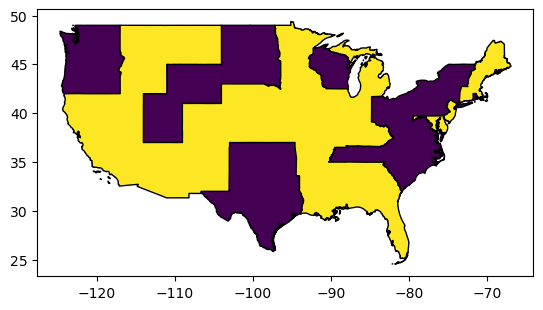

In [34]:
# Alphabetically, assign last 20 states "Other USA"
country.loc[30:,"country"] = "Other USA"
# Dissolve
dissolved = country.dissolve(by="country",aggfunc="max")
# Sum
dissolved.plot(edgecolor="black",column="fire_number")

So now we have dissolved multiple states into one polygon. Dissolves are useful when you want to change the level of analysis.

## Step 2: Read in rasters

 Let's read in a raster file, in this case annual precipitation data from 2017 from [PRISM](https://prism.oregonstate.edu/recent/), a great source of historical weather data. 
 
 The package for reading in raster files is called `rasterio`

In [35]:
import rasterio
# The name of the raster file
raster_file = "PRISM_ppt_stable_4kmM3_2017_bil.bil"
# Read it in from the data directory
raster = rasterio.open(data_dir+raster_file)

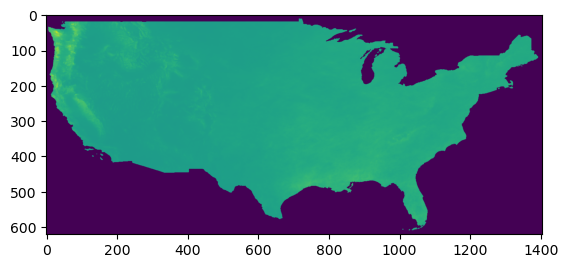

In [36]:
# Show the first band of the raster
plt.imshow(raster.read()[0,:,:])

In this case, the file format is a .bil not a .tif

#### Projection check:

In [37]:
# Is the raster crs the same as country crs?
raster.crs==country_proj.crs

False

What are the CRSs?

In [38]:
# Of the country
print(country_proj.crs)
# Of the raster
raster.crs

EPSG:4087


CRS.from_wkt('GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]')

So this is not what our shapefile currently is because we reprojected it...

Two ways we can go about this:
1. Reproject the raster file to match the shapefile (harder).
2. Reproject the shapefile to match the raster (easier).

It takes only one line to reproject geopandas dataframes, but much more code to do the same for rasterio. Here I'll demonstrate the raster way.

So what is the raster object anyway?

In [39]:
raster.width,\
raster.height,\
raster.bounds

(1405,
 621,
 BoundingBox(left=-125.0208333333335, bottom=24.0624999997925, right=-66.4791666661985, top=49.9374999999995))

Notice that it is almost the same as a numpy array but it embeds geographic information. The function `read` will transform it into a numpy array.

In [40]:
type(raster.read()),\
raster.read().shape

(numpy.ndarray, (1, 621, 1405))

How can we use this info to translate it into a different coordinate system?

In [41]:
raster.transform

Affine(0.041666666667, 0.0, -125.0208333333335,
       0.0, -0.041666666667, 49.9374999999995)

Each raster contains an "affine transformation" which translates the pixel coordinates into geographic coordinates.

According to the docs, the above are coefficients to this equation:

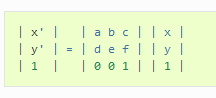

### Reprojecting a Raster

Essentially, we need to create a function that translates one "transformation" into another. We need to take the measurements of the first system and create a function that translates into a new system.

Now let's look at some code from [this question](https://gis.stackexchange.com/questions/337528/rasterio-reprojection-doesnt-seem-to-work]):

In [42]:
import numpy as np
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
import geopandas
# Source file is original raster
src_file = raster_file
# This is the name of the destination raster
dst_file = 'ppt_reproj.tif'
# Destination CRS
dst_crs = rasterio.crs.CRS.from_dict({'init': 'EPSG:4087'})

The following code does the reprojection... but what is it actually doing?

In [58]:
with rasterio.open(data_dir+src_file) as src: 
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds) 
    kwargs = src.meta.copy() 
    kwargs.update({
        'crs': dst_crs,
        'transform': transform,
        'width': width,
        'height': height
    })
    with rasterio.open(dst_file, 'w', **kwargs) as dst: 
        for i in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=rasterio.band(dst, i),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.nearest)

In [43]:
# Open the new raster 
raster = rasterio.open("./ppt_reproj.tif")
# Look at CRS
raster.crs

CRS.from_wkt('PROJCS["WGS 84 / World Equidistant Cylindrical",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Equirectangular"],PARAMETER["standard_parallel_1",0],PARAMETER["central_meridian",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]')

In [44]:
# Read in first band
ppt = raster.read(1)
# Look at data
ppt

array([[-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       ...,
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.]],
      dtype=float32)

So now we have a Numpy array. Here's what it looks like plotted:

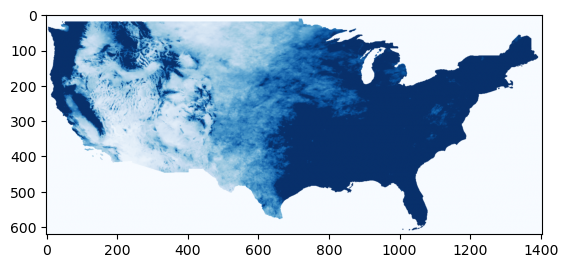

In [46]:
# Plot the reprojected raster
plt.imshow(ppt,cmap="Blues", vmin=0,vmax=1000)

##### Reminder

the difference between a raster and a usual numpy array is that rasters are georeferenced. So rasters have info like this:

In [47]:
# What is the CRS?
raster.crs

CRS.from_wkt('PROJCS["WGS 84 / World Equidistant Cylindrical",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Equirectangular"],PARAMETER["standard_parallel_1",0],PARAMETER["central_meridian",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]')

In [48]:
# What is the bounding box?
raster.bounds

BoundingBox(left=-13917255.50521741, bottom=2678625.659265449, right=-7400426.981642393, top=5559017.483564442)

But reading it as a numpy array it no longer has this data, it's simply a matrix.

To understand why this important, lets look at what it would take to "clip" a raster to a specific state like Illinois...

### Clipping and Editing Rasters

What if we only wanted a raster of Illinois and not the entire US? We would have to essentially "mask" the raster just we like would usually mask an array, but this time omit everything outside of the Illinois border.

The way this works:
1. Find the Illinois coordinates
2. Use the rasterio "mask" function to get back an edited array.
    - NOTE: when we do this, the resulting array LOSES its geographic data, so we have to write it back with the geographic information.
3. Re-embed geographic data
4. Write out clipped raster
5. Read it back in

#### 1. Find the Illinois Coordinates
Each geopandas geometry object contains the coordinates that the rasterio function wants.

In [50]:
import json
# Select just the Illinois row
illinois_row = country_proj[country_proj.NAME=="Illinois"]
# Load in the json object from the geometry
illinois_json = json.loads(illinois_row['geometry'].to_json())
# Showing the geometry of the feature
illinois_json['features'][0]['geometry']

{'type': 'Polygon',
 'coordinates': [[[-9948181.065135902, 4731108.860254603],
   [-9947683.467012053, 4731079.694548016],
   [-9939817.075195147, 4730950.675258187],
   [-9935349.04479318, 4730855.0518155955],
   [-9934927.477881545, 4730870.191266344],
   [-9932846.582640145, 4730860.951748608],
   [-9932622.941783143, 4730850.9329944365],
   [-9925994.75666233, 4730772.898031389],
   [-9925791.821230613, 4730783.028105051],
   [-9921361.973413985, 4730739.613503642],
   [-9920833.65111068, 4730743.50968582],
   [-9920453.383730132, 4730734.381487575],
   [-9918456.64602377, 4730688.62917686],
   [-9915354.060495872, 4730656.235205038],
   [-9912210.064117396, 4730661.4672211055],
   [-9908971.334852258, 4730643.8787415605],
   [-9908956.084082019, 4730642.7655466525],
   [-9906652.883817507, 4730635.975057715],
   [-9906617.484219434, 4730635.863738224],
   [-9901118.8579717, 4730534.451682111],
   [-9900799.037074652, 4730526.881956737],
   [-9900798.703116179, 4730526.881956737],


This is the data we need to load into the function, so we can make a fancy function (this is from [this documentation](https://automating-gis-processes.github.io/CSC18/lessons/L6/clipping-raster.html)):

Essentially, this function takes a GeoDataFrame and extracts the coordinates it needs.

In [51]:
def getFeatures(gdf):
    """Function to parse features from GeoDataFrame in such a manner that rasterio wants them"""
    import json
    return [json.loads(gdf.to_json())['features'][0]['geometry']]
# Illinois row
IL_row = country_proj[country_proj.NAME=="Illinois"]
# Get coordinates using the function
IL_coords = getFeatures(IL_row)

What they look like plotted:

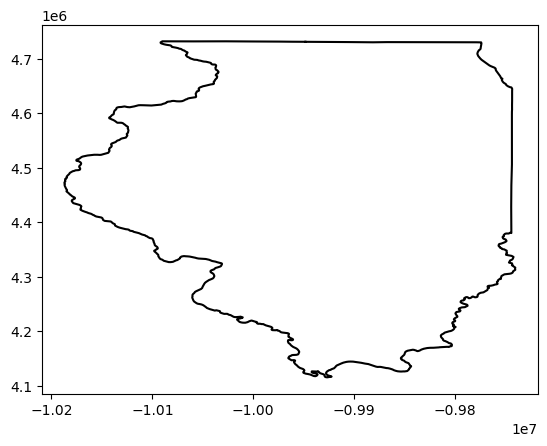

In [52]:
# Converting coordinates to array
coords = np.array(IL_coords[0]['coordinates'][0])
# Plot the x and y
plt.plot(coords[:,0],coords[:,1],color='black')

Rasterio has its own `mask` function that can help us with this. It takes the raster object as the first argument and our coordinates as the second:

In [53]:
from rasterio.mask import mask
# The two arguments for the mask function are:
# The raster you want to clip
# The thing you want to clip it to
img_out, img_transform = mask(raster,IL_coords)

Plotted it looks like this:

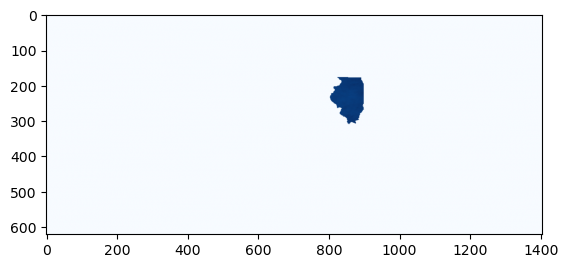

In [54]:
# Show the image I clipped
plt.imshow(img_out[0],cmap="Blues")

So now we have just Illinois. But notice now that the indices dont have anything to do with geo-coordinates. How do we get this info back?

The second output of the function "mask" is the directions on how to translate them back:

In [55]:
img_transform

Affine(4638.3121164235, 0.0, -13917255.50521741,
       0.0, -4638.3121164235, 5559017.483564442)

To make this a raster again, we can write it back as a raster while re-embedding the metadata

In [56]:
# Copy the previous metadata
out_meta = raster.meta.copy()
# Update the parameters
out_meta['height'] = img_out.shape[1]
out_meta['width'] = img_out.shape[2]
out_meta['transform'] = img_transform
# Using a new file ("IL_PPT.tif"), write out the raster
with rasterio.open("./IL_PPT.tif", "w", **out_meta) as dest:
    dest.write(img_out)

In [57]:
# Read it back in again
IL_raster = rasterio.open("./IL_PPT.tif")

In [58]:
IL_raster.read(1)

array([[-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       ...,
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.]],
      dtype=float32)

<Axes: >

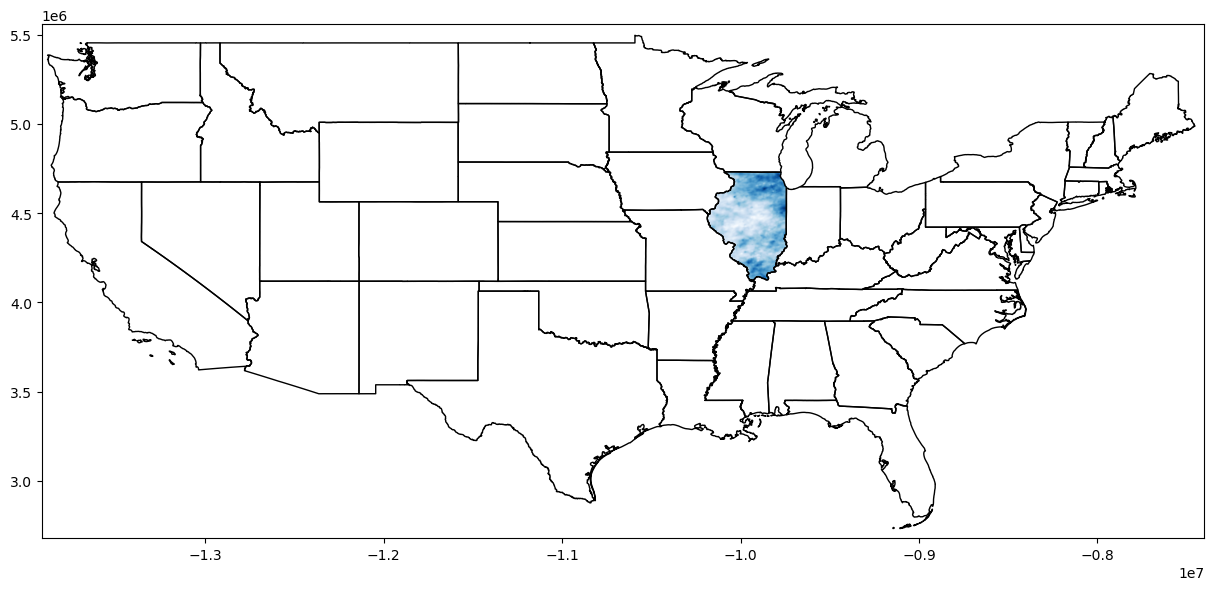

In [59]:
from rasterio.plot import show
# Create a figure
fig, ax = plt.subplots(figsize=(15, 15))
# Show the IL_raster on "ax"
rasterio.plot.show(IL_raster, ax=ax,cmap="Blues")
# Plot the entire US
country_proj.plot(ax=ax, facecolor='none', edgecolor='black')

Nice!

With this technique, a huge upside is that __we can edit rasters just like numpy arrays__ as long as we write the data back with the right metadata.

For example, what if we wanted a raster of zeros and ones indicating if rainfall hits a certain threshhold, for example the state average?

### Making a New Raster

In [60]:
import pandas as pd
# Flatten image into one column
IL_vals = pd.Series(IL_raster.read(1).flatten())
# Leave out background pixels
IL_avg = IL_vals[IL_vals!=-9999].mean()

In [62]:
IL_avg

973.25

Do it like this: 

In [64]:
# Read in new version of the raster
IL_r_vals = IL_raster.read(1)

In [65]:
# Binary array based on average
binary_array = (IL_r_vals>IL_avg)[np.newaxis,:,:]
# Write out, but with float32
img_out = binary_array.astype(np.float32)

__NOTE:__ A couple of things happened up there:

`img_out = (IL_r_vals>IL_avg)[np.newaxis,:,:].astype(np.float32)`

1. We made a boolean array by coding "True" if the rainfall was above the average
2. We added an axis so the array is three dimensions using "np.newaxis"; raster always are three dimensional arrays, the first dimension being the band and the second and third being the rows and the columns. We need to put a "band" dimension into any array before it can be written to raster.
3. We converted the "booleans" to float32 to make it play nice with Rasterio

Now change the metadata

In [66]:
# Copy the metadata
out_meta = IL_raster.meta.copy()
# Update the parameters
out_meta['height'] = img_out.shape[1]
out_meta['width'] = img_out.shape[2]
out_meta['transform'] = img_transform
# Write it out as "example.tif"
with rasterio.open("./example.tif", "w", **out_meta) as dest:
    dest.write(img_out)

(4099999.9999999995, 4800000.0)

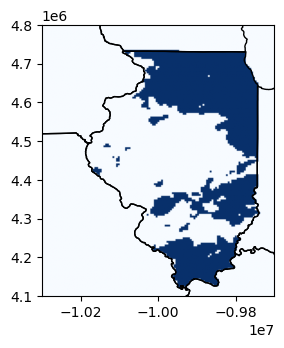

In [67]:
# Read it back in
IL_raster = rasterio.open("./example.tif")

fig, ax = plt.subplots(figsize=(3, 5))
# Plot the new raster
rasterio.plot.show(IL_raster, ax=ax,cmap="Blues")
# Plot the country
country_proj.plot(ax=ax, facecolor='none', edgecolor='black')
# Limit view to Illinois
plt.xlim(-1.03*10**7,-.97*10**7)
plt.ylim(4.1*10**6,4.8*10**6)

### The above is an important skill for Homework 2

## Step 3: Zonal Statistics

The next step is doing some basic zonal statistics. Zonal statistics are one way to summarize a raster file using a vector file.

Here we will find the average rainfall for that year for all the counties in Illinois.

### Country-wide

First, let's start with the whole country.

The package "rasterstats" is very convenient for this. Its function "zonal_stats" takes two arguments:
1. Shapefile path, polygon object, or geopandas dataframe
2. Raster file path, or a numpy array if you supply "transform" to tell it coordinates.

In [68]:
from rasterstats import zonal_stats
# The two arguments for this function are
#  1. Shapefile
#  2. Raster
zonal_stats(country_proj, "./ppt_reproj.tif")[:3]

[{'min': 1148.89208984375,
  'max': 2756.134033203125,
  'mean': 1706.3798710024187,
  'count': 7442},
 {'min': 58.06500244140625,
  'max': 983.2120361328125,
  'mean': 241.176297276171,
  'count': 16631},
 {'min': 834.4190673828125,
  'max': 1702.319091796875,
  'mean': 1307.564802885854,
  'count': 7762}]

Returns a list of dictionaries that can be made into a dataframe:

In [69]:
import pandas as pd

# Save the stats as an object
stats = zonal_stats(country_proj, "./ppt_reproj.tif")
# Convert that to a dataframe
rain_stats = pd.DataFrame(stats)
# Look at the shape
rain_stats.shape

(49, 4)

In [70]:
rain_stats.head(5)

,min,max,mean,count
0,1148.892090,2756.134033,1706.379871,7442
1,58.065002,983.212036,241.176297,16631
2,834.419067,1702.319092,1307.564803,7762
3,35.570004,5572.697266,761.214628,24009
4,133.687012,1926.190063,509.372574,16233


Notice there are 49 rows, which is the same as `country_proj`:

In [71]:
country_proj.shape

(49, 7)

This function calculates stats and returns the stats unlabeled but in the same order as the input shapefile.

This means we just concatenate our dataframes:

In [72]:
# Rename the columns, with "rain_" coming before each name
rain_stats.columns = ["rain_"+x for x in rain_stats.columns]
# HArmonize the indices (to concat)
rain_stats.index = country_proj.index
# Concate them together
country_rain = pd.concat([country_proj,rain_stats],axis=1)

In [73]:
country_rain.head()

,GEO_ID,STATE,NAME,LSAD,CENSUSAREA,geometry,bama_dist,rain_min,rain_max,rain_mean,rain_count
0,0400000US01,01,Alabama,,50645.326,"MULTIPOLYGON (((-9809992.055 3371159.384, -980...",0.000000,1148.892090,2756.134033,1706.379871,7442
2,0400000US04,04,Arizona,,113594.084,"POLYGON ((-12527738.867 4118896.189, -12527288...",2769.813683,58.065002,983.212036,241.176297,16631
3,0400000US05,05,Arkansas,,52035.477,"POLYGON ((-10468814.865 3675682.645, -10468822...",667.304299,834.419067,1702.319092,1307.564803,7762
4,0400000US06,06,California,,155779.220,"MULTIPOLYGON (((-13627892.252 4215665.665, -13...",3682.871823,35.570004,5572.697266,761.214628,24009
5,0400000US08,08,Colorado,,103641.888,"POLYGON ((-11821078.398 4563832.735, -11806676...",2195.467397,133.687012,1926.190063,509.372574,16233


<Axes: >

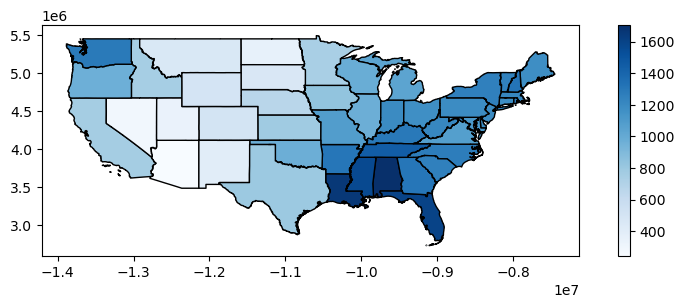

In [74]:
f,a = plt.subplots(figsize=(10,3))
# Plot the geodataframe
country_rain.plot(column="rain_mean", # Use the average rainfall
                  cmap="Blues", # Colormap set to blues
                  legend=True, # Use a color bar
                  ax=a, # Put it on axis "a"
                  edgecolor="black") # color the edges black

### With counties

<Axes: >

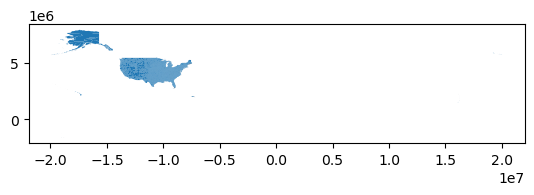

In [75]:
# Read in counties shapefile
counties = geopandas.read_file(data_dir+"us_counties_2017.shp")

# Reproject counties to the country shapefile
counties = counties.to_crs(country_proj.crs)

counties.plot()

Subset to Illinois:

<Axes: >

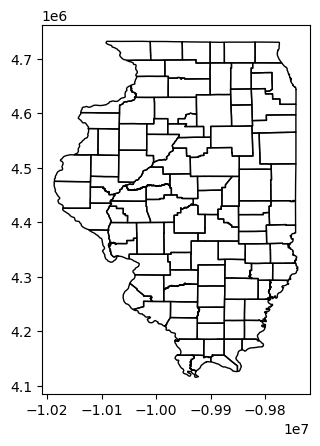

In [76]:
# Select counties with state fips code of 17
IL_counties = counties[counties['STATEFP'] == "17"]
# Plot them
IL_counties.plot(edgecolor="black",facecolor="none")

Now do the rasterstats as before.

In [77]:
from rasterstats import zonal_stats
# Reminder: the inputs to this function are
# 1. The shapefile
# 2. The rainfall raster
zonal_stats(IL_counties, "./ppt_reproj.tif")

[{'min': 1079.4630126953125,
  'max': 1349.717041015625,
  'mean': 1243.9564426369864,
  'count': 73},
 {'min': 716.6260375976562,
  'max': 895.7780151367188,
  'mean': 806.95,
  'count': 90},
 {'min': 996.6900634765625,
  'max': 1265.758056640625,
  'mean': 1113.7713994565217,
  'count': 138},
 {'min': 812.3440551757812,
  'max': 979.0570678710938,
  'mean': 878.5792410714286,
  'count': 70},
 {'min': 1028.9639892578125,
  'max': 1229.988037109375,
  'mean': 1139.410887096774,
  'count': 155},
 {'min': 845.7640380859375,
  'max': 1053.7969970703125,
  'mean': 938.0377604166666,
  'count': 33},
 {'min': 807.800048828125,
  'max': 967.9600219726562,
  'mean': 898.7641256313132,
  'count': 99},
 {'min': 752.60205078125,
  'max': 854.655029296875,
  'mean': 803.3509615384615,
  'count': 52},
 {'min': 869.3130493164062,
  'max': 1003.6940307617188,
  'mean': 927.1631324404761,
  'count': 42},
 {'min': 856.4390258789062,
  'max': 989.9580688476562,
  'mean': 897.3748739919355,
  'count': 31

In [78]:
# Make a dataframe out of the output
county_rain_stats = pd.DataFrame(zonal_stats(IL_counties, "./ppt_reproj.tif"))
# Rename all the columns
county_rain_stats.columns = ["rain_"+x for x in county_rain_stats.columns]

# Harmonize the indices
county_rain_stats.index = IL_counties.index
# Concat them together
IL_counties = pd.concat([IL_counties,county_rain_stats],axis=1)

<Axes: >

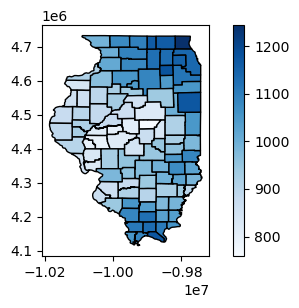

In [79]:
f,a = plt.subplots(figsize=(6,3))
# Plot using geopandas plotting function
IL_counties.plot(column="rain_mean", # The column you're using to color 
                 cmap="Blues", # Colormap
                 legend=True, # MAke a colorbar
                 ax=a, # Plot on that axis
                 edgecolor="black") # Make the edges black

Simple as that!